In [15]:
%pip install geopandas folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 3.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [16]:
import geopandas as gpd
import pandas as pd

nychares_df = pd.read_csv('../cleaned_data/nycha_residential.csv')
pluto_df  = pd.read_csv('../cleaned_data/cleaned_PLUTO.csv')

nycha_gdf = gpd.GeoDataFrame(
    nychares_df,
    geometry=gpd.points_from_xy(nychares_df['longitude'], nychares_df['latitude']),
    crs='EPSG:2263'
)

pluto_gdf = gpd.GeoDataFrame(
    pluto_df,
    geometry=gpd.points_from_xy(pluto_df['longitude'], pluto_df['latitude']),
    crs='EPSG:2263'
)

In [17]:

pluto_gdf['bbl']  = pluto_gdf['bbl'].astype(str).str.strip()
nycha_gdf = nycha_gdf.rename(columns={'borough/block/lot_#': 'BBL'})

In [18]:
pluto_attrs = pluto_gdf.drop(columns='geometry')

In [19]:
pluto_attrs['bbl'] = pluto_attrs['bbl'].astype('int64')

combined_gdf = nycha_gdf.merge(
    pluto_attrs,
    left_on='BBL',
    right_on='bbl',
    how='left',
    suffixes=('_nycha', '_pluto')
)

combined_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 93 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   development                        2961 non-null   object  
 1   tds_#                              2961 non-null   int64   
 2   building_#                         2961 non-null   object  
 3   stairhall#                         2961 non-null   int64   
 4   borough_nycha                      2961 non-null   object  
 5   house_#                            2961 non-null   object  
 6   street                             2961 non-null   object  
 7   address_nycha                      2961 non-null   object  
 8   city                               2961 non-null   object  
 9   state                              2961 non-null   object  
 10  zip_code                           2961 non-null   object  
 11  bin                                

In [20]:
print(f"NYCHA rows:    {len(nycha_gdf)}")
print(f"Combined rows: {len(combined_gdf)}")

NYCHA rows:    2961
Combined rows: 2961


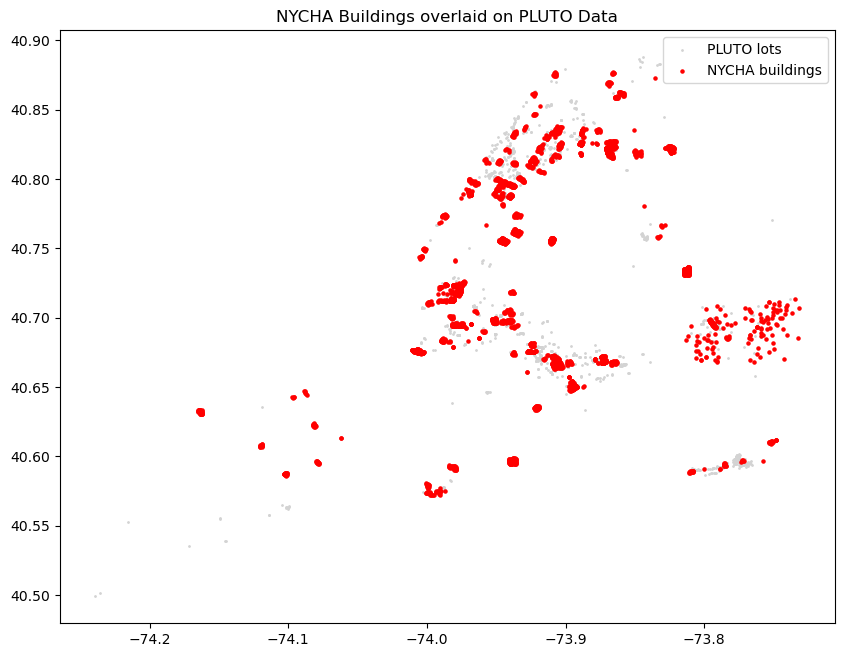

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

# Plot PLUTO lot points as a light background reference
pluto_gdf.plot(ax=ax, color='lightgrey', markersize=1, label='PLUTO lots')

# Plot NYCHA points on top
combined_gdf.plot(ax=ax, color='red', markersize=5, label='NYCHA buildings')

ax.set_title('NYCHA Buildings overlaid on PLUTO Data')
ax.legend()
plt.show()

In [22]:
# Check a sample of rows to confirm PLUTO columns populated correctly
combined_gdf[['BBL', 'bbl', 'development', 'landuse', 'yearbuilt']].sample(10)

,BBL,bbl,development,landuse,yearbuilt
2017,4004650001,4.004650e+09,QUEENSBRIDGE SOUTH,3.0,1939.0
209,3081740001,3.081740e+09,BREUKELEN,3.0,1951.0
1527,5012450001,5.012450e+09,MARINER'S HARBOR,3.0,1953.0
1410,1004160001,1.004160e+09,LOWER EAST SIDE I INFILL,2.0,1986.0
1042,3079780001,3.079780e+09,GLENWOOD,3.0,1948.0
259,3016880001,3.016880e+09,BREVOORT,3.0,1980.0
2436,4101250033,4.101250e+09,SOUTH JAMAICA I,2.0,1942.0
2570,2055820001,2.055820e+09,THROGGS NECK,3.0,1952.0
2752,1002670024,1.002670e+09,VLADECK,3.0,1940.0
240,3081580001,3.081580e+09,BREUKELEN,3.0,1950.0


In [23]:
import folium
from folium.plugins import MarkerCluster

# Center map on NYC
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Add NYCHA points as clustered markers
marker_cluster = MarkerCluster().add_to(m)

for _, row in combined_gdf.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"BBL: {row['BBL']}<br>Development: {row.get('development', 'N/A')}",
    ).add_to(marker_cluster)

m

In [24]:
combined_gdf.to_csv('../cleaned_data/combined_nychares_pluto.csv', index = False)

In [25]:
# Load electric consumption and cost data

electricity_consumption_cost_df = pd.read_csv('../raw_data/Electric_Consumption_And_Cost_(2010_-_Sep_2025)_20260314.csv')


# Clean data

electricity_consumption_cost_df_cleaned = electricity_consumption_cost_df.copy()

electricity_consumption_cost_df_cleaned.columns= (electricity_consumption_cost_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

# Drop columns

electricity_consumption_cost_df_cleaned.drop(columns=['edp', 'account_name', 'location', 'meter_amr',
       'meter_scope', 'umis_bill_id', 'amp_#', 'rc_code', 'estimated','rate_class','bill_analyzed'])

,development_name,borough,tds_#,funding_source,vendor_name,revenue_month,service_start_date,service_end_date,#_days,meter_number,current_charges,consumption_(kwh),kwh_charges,consumption_(kw),kw_charges,other_charges
0,SHEEPSHEAD BAY,BROOKLYN,36.0,FEDERAL,NEW YORK POWER AUTHORITY,2025-09,08/21/2025,09/22/2025,32.0,12787077,"$5,106.45","33,001","$1,523.76",0,$0,"$3,582.69"
1,SHEEPSHEAD BAY,BROOKLYN,36.0,FEDERAL,NEW YORK POWER AUTHORITY,2025-09,08/21/2025,09/22/2025,32.0,12786820,"$5,581.02","36,068","$1,665.38",0,$0,"$3,915.64"
2,SHEEPSHEAD BAY,BROOKLYN,36.0,FEDERAL,NEW YORK POWER AUTHORITY,2025-09,08/21/2025,09/22/2025,32.0,4499227,"$4,791.96","30,969","$1,429.94",0,$0,"$3,362.02"
3,SHEEPSHEAD BAY,BROOKLYN,36.0,FEDERAL,NEW YORK POWER AUTHORITY,2025-09,08/21/2025,09/22/2025,32.0,12787144,"$6,225.81","40,235","$1,857.78",0,$0,"$4,368.03"
4,SHEEPSHEAD BAY,BROOKLYN,36.0,FEDERAL,NEW YORK POWER AUTHORITY,2025-09,08/21/2025,09/22/2025,32.0,12787064,"$5,254.21","33,956","$1,567.86",0,$0,"$3,686.35"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553661,TAYLOR STREET-WYTHE AVENUE,BROOKLYN,234.0,FEDERAL,NEW YORK POWER AUTHORITY,2010-01,12/24/2009,01/26/2010,33.0,6815000,"$16,688.82","130,000","$7,456.8",248,"$3,224","$6,008.02"
553662,REDFERN,QUEENS,55.0,FEDERAL,Long Island Power Authority,2010-01,12/23/2009,01/26/2010,34.0,300987,"$53,651.93","353,000","$12,060.3",0,"$3,240.74","$38,350.89"
553663,MARCY,BROOKLYN,21.0,FEDERAL,NEW YORK POWER AUTHORITY,2010-01,12/24/2009,01/26/2010,33.0,1009854,"$1,507.9",0,$0,75.17,$977.21,$530.69
553664,MARCY,BROOKLYN,21.0,FEDERAL,NEW YORK POWER AUTHORITY,2010-01,12/24/2009,01/26/2010,33.0,1833954,"$1,507.9",0,$0,75.17,$977.21,$530.69


In [26]:
electricity_consumption_cost_df_cleaned['consumption_(kwh)'] = (
    electricity_consumption_cost_df_cleaned['consumption_(kwh)']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)

electricity_consumption_cost_df_cleaned = electricity_consumption_cost_df_cleaned.dropna(subset=['tds_#'])

electricity_consumption_cost_df_cleaned['tds_#'] = (
    electricity_consumption_cost_df_cleaned['tds_#']
    .astype(float)
    .astype(int)
    .astype(str)
)

electricity_consumption_cost_df_cleaned['current_charges'] = (
    electricity_consumption_cost_df_cleaned['current_charges']
    .astype(str)
    .str.replace('[$,]', '', regex=True)
    .str.strip()
)
electricity_consumption_cost_df_cleaned['current_charges'] = pd.to_numeric(electricity_consumption_cost_df_cleaned['current_charges'], errors='coerce')

In [27]:
electricity_consumption_cost_df_cleaned['tds_#'].value_counts().head(20)

tds_#
57     10837
2      10395
48     10239
56      9449
63      9278
67      9026
21      8573
53      8476
83      8469
16      8284
39      7882
377     7330
4       7259
26      7192
74      7124
61      7069
92      6613
6       6558
33      6533
44      6267
Name: count, dtype: int64

In [28]:
electricity_consumption_cost_df_cleaned['tds_#'] = (
    electricity_consumption_cost_df_cleaned['tds_#']
    .astype(str)
    .str.replace(',', '')
    .str.strip()
    .str.replace(r'\.0$', '', regex=True)  # remove trailing .0
)

print(electricity_consumption_cost_df_cleaned['tds_#'].head(10).tolist())  # verify before aggregating

['36', '36', '36', '36', '36', '36', '36', '36', '36', '36']


In [29]:
# Aggregate columns

electricity_consumption_agg = (
    electricity_consumption_cost_df_cleaned
    .groupby('tds_#')
    .agg({
        'consumption_(kwh)': 'sum',
        'current_charges': 'sum',
        'borough': 'first'
    })
    .reset_index()
)
electricity_consumption_agg.head()

,tds_#,consumption_(kwh),current_charges,borough
0,0,1.034308e+08,17344763.12,MANHATTAN
1,1,3.195641e+06,455549.90,MANHATTAN
2,10,8.720041e+07,12031729.15,BROOKLYN
3,100,5.357564e+07,8034960.18,MANHATTAN
4,101,6.638506e+07,9340877.35,MANHATTAN


In [30]:
# Merge

combined_gdf['tds_#'] = combined_gdf['tds_#'].astype(str).str.strip()
electricity_consumption_agg['tds_#'] = electricity_consumption_agg['tds_#'].astype(str).str.strip()

final_gdf = combined_gdf.merge(electricity_consumption_agg, on='tds_#', how='left')
print(final_gdf['consumption_(kwh)'].isna().sum())
print(final_gdf[['development', 'tds_#', 'consumption_(kwh)']].head(10))

49
                   development tds_#  consumption_(kwh)
0  1162-1176 WASHINGTON AVENUE   233          8712982.0
1           1471 WATSON AVENUE   214          9580048.0
2         154 WEST 84TH STREET   359          2191151.0
3            303 VERNON AVENUE   156         24744232.0
4              45 ALLEN STREET   265         13181295.0
5         830 AMSTERDAM AVENUE   150         19069795.0
6                        ADAMS   118         97995861.0
7                        ADAMS   118         97995861.0
8                        ADAMS   118         97995861.0
9                        ADAMS   118         97995861.0


In [31]:
electricity_consumption_cost_df_cleaned.columns.tolist()

['development_name',
 'borough',
 'account_name',
 'location',
 'meter_amr',
 'meter_scope',
 'tds_#',
 'edp',
 'rc_code',
 'funding_source',
 'amp_#',
 'vendor_name',
 'umis_bill_id',
 'revenue_month',
 'service_start_date',
 'service_end_date',
 '#_days',
 'meter_number',
 'estimated',
 'current_charges',
 'rate_class',
 'bill_analyzed',
 'consumption_(kwh)',
 'kwh_charges',
 'consumption_(kw)',
 'kw_charges',
 'other_charges']

In [32]:
# Generate top 10 developments by aggregate consumption

final_gdf.groupby('development')['consumption_(kwh)'].sum().sort_values(ascending=False).head(10)

development
POMONOK                 2.210931e+10
BREUKELEN               1.470409e+10
MARCY                   1.077808e+10
RAVENSWOOD              9.241181e+09
THROGGS NECK            8.036913e+09
CLASON POINT GARDENS    7.614483e+09
BARUCH                  7.306637e+09
RED HOOK EAST           7.017741e+09
WOODSIDE                6.903743e+09
INGERSOLL               6.194968e+09
Name: consumption_(kwh), dtype: float64

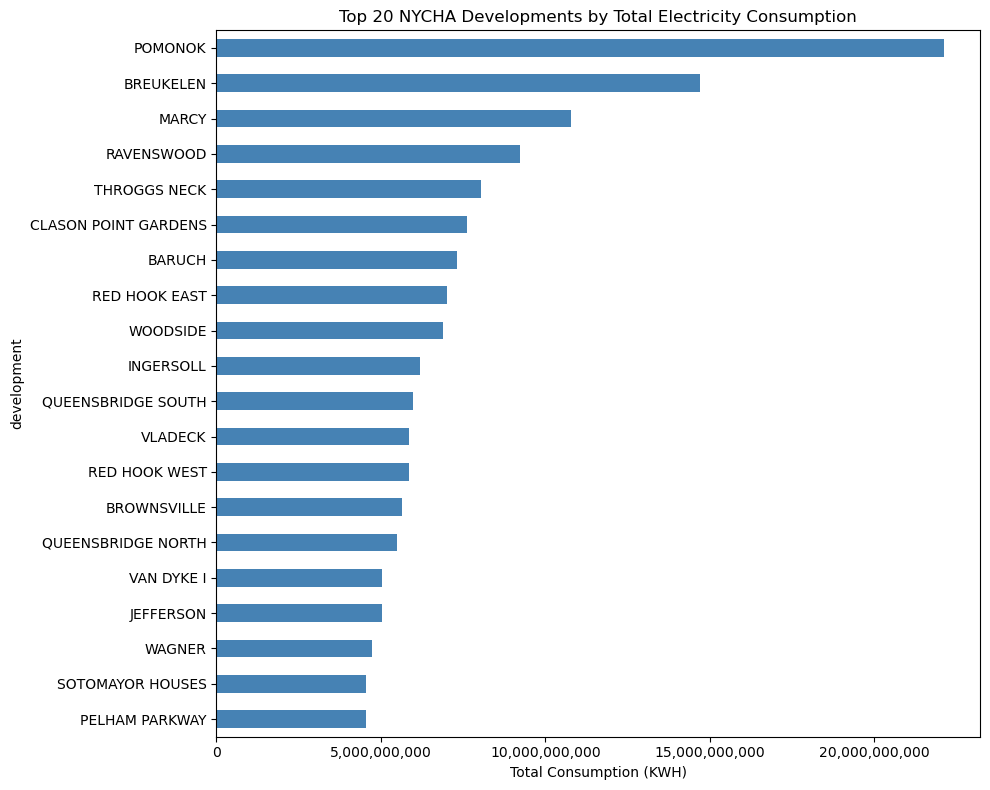

In [ ]:
# Top 20 developments by total electricity consumption

import matplotlib.pyplot as plt

top20_total = (
    final_gdf.groupby('development')['consumption_(kwh)']
    .sum()
    .sort_values(ascending=True)
    .tail(20)
)

fig, ax = plt.subplots(figsize=(10, 8))
top20_total.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Total Consumption (KWH)')
ax.set_title('Top 20 NYCHA Developments by Total Electricity Consumption')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

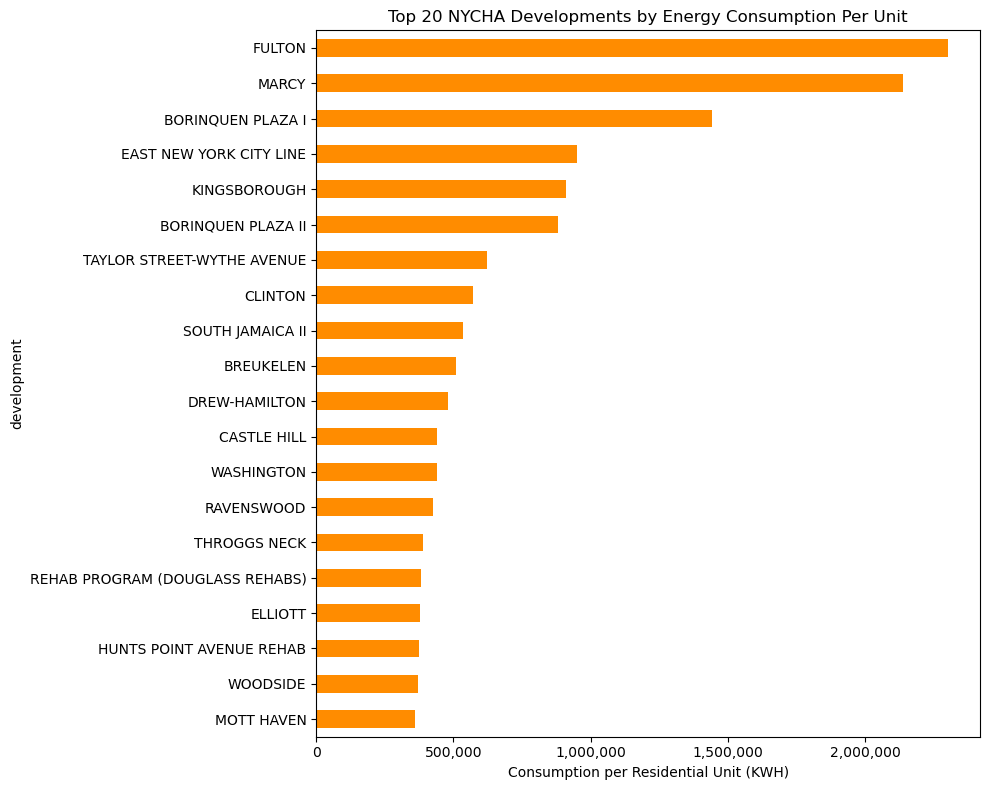

In [ ]:
# Top 20 developments by electricity consumption per unit

final_gdf['consumption_(kwh)'] = pd.to_numeric(final_gdf['consumption_(kwh)'], errors='coerce')
final_gdf['unitsres'] = pd.to_numeric(final_gdf['unitsres'], errors='coerce')

final_gdf['consumption_per_unit'] = final_gdf['consumption_(kwh)'] / final_gdf['unitsres']

top20_perunit = (
    final_gdf.dropna(subset=['development', 'consumption_per_unit'])
    .groupby('development')['consumption_per_unit']
    .mean()
    .sort_values(ascending=True)
    .tail(20)
)


fig, ax = plt.subplots(figsize=(10, 8))
top20_perunit.plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('Consumption per Residential Unit (KWH)')
ax.set_title('Top 20 NYCHA Developments by Electricity Consumption Per Unit')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

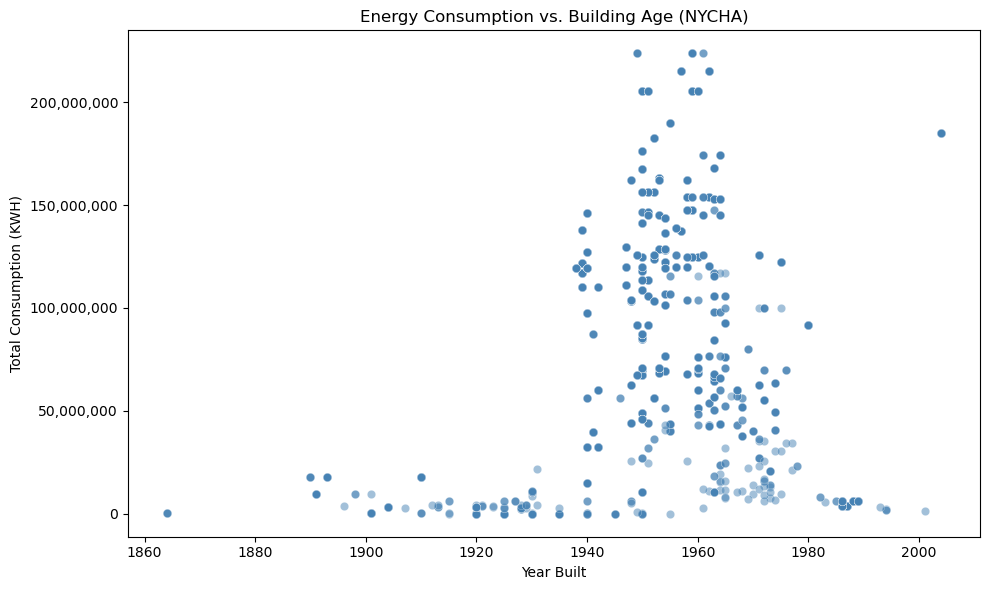

In [ ]:
# Electricity consumption vs building age

fig, ax = plt.subplots(figsize=(10, 6))

scatter_df = final_gdf.dropna(subset=['yearbuilt', 'consumption_(kwh)'])
scatter_df = scatter_df[scatter_df['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df['yearbuilt'], scatter_df['consumption_(kwh)'],
           alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Total Consumption (KWH)')
ax.set_title('Electricity Consumption vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

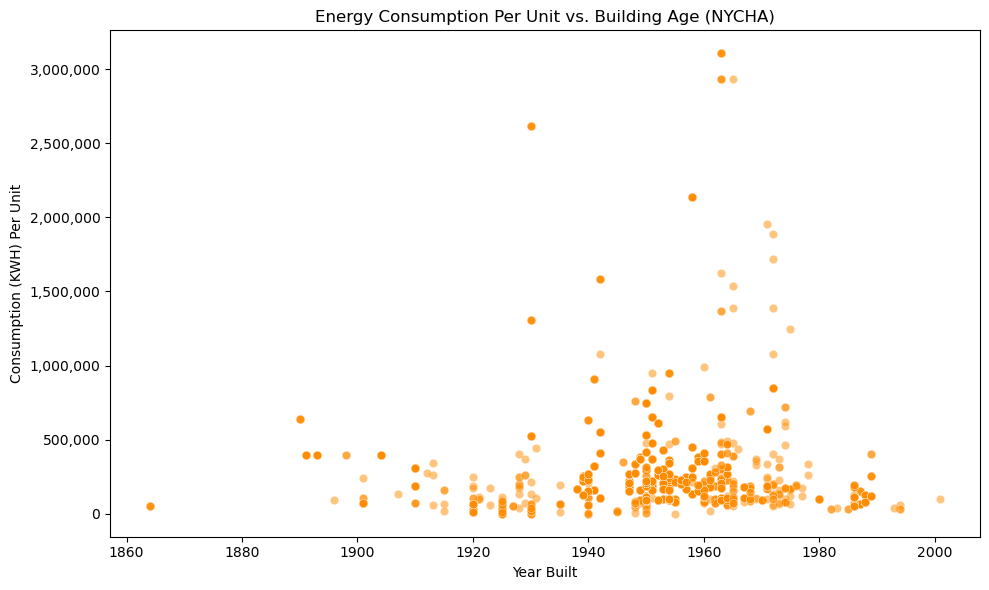

In [ ]:
# Electricity consumption per unit vs building age

fig, ax = plt.subplots(figsize=(10, 6))

scatter_df2 = final_gdf.dropna(subset=['yearbuilt', 'consumption_per_unit'])
scatter_df2 = scatter_df2[scatter_df2['yearbuilt'] > 0]  # drop placeholder 0s

ax.scatter(scatter_df2['yearbuilt'], scatter_df2['consumption_per_unit'],
           alpha=0.5, color='darkorange', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Year Built')
ax.set_ylabel('Consumption (KWH) Per Unit')
ax.set_title('Energy Consumption Per Unit vs. Building Age (NYCHA)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

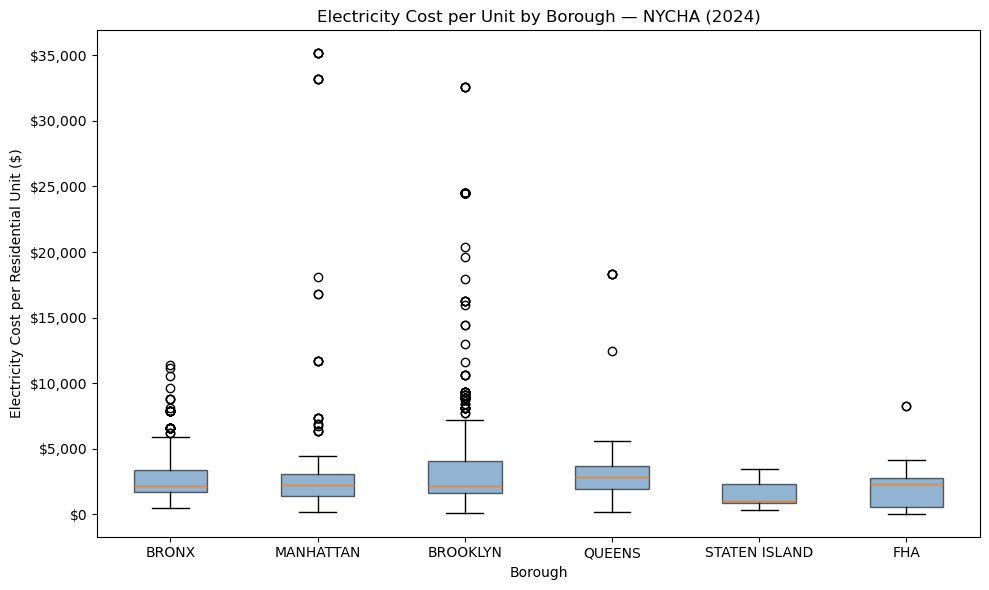

In [ ]:
# Electricity costs per unit by borough

electricity_consumption_cost_df_cleaned['revenue_month'] = pd.to_datetime(electricity_consumption_cost_df_cleaned['revenue_month'])
electricity_consumption_2024 = electricity_consumption_cost_df_cleaned[
    electricity_consumption_cost_df_cleaned['revenue_month'].dt.year == 2024
].copy()

# Clean and aggregate
electricity_consumption_2024['current_charges'] = (
    electricity_consumption_2024['current_charges']
    .astype(str)
    .str.replace('[$,]', '', regex=True)
    .str.strip()
)
electricity_consumption_2024['current_charges'] = pd.to_numeric(electricity_consumption_2024['current_charges'], errors='coerce')

electricity_consumption_agg_2024 = (
    electricity_consumption_2024
    .groupby('tds_#')
    .agg({
        'consumption_(kwh)': 'sum',
        'current_charges': 'sum',
        'borough': 'first'
    })
    .reset_index()
)

electricity_consumption_agg_2024['tds_#'] = electricity_consumption_agg_2024['tds_#'].astype(str).str.strip()
combined_gdf['tds_#'] = combined_gdf['tds_#'].astype(str).str.strip()

final_gdf_2024 = combined_gdf.merge(electricity_consumption_agg_2024, on='tds_#', how='left')
final_gdf_2024['current_charges'] = pd.to_numeric(final_gdf_2024['current_charges'], errors='coerce')
final_gdf_2024['unitsres'] = pd.to_numeric(final_gdf_2024['unitsres'], errors='coerce')

# Calculate cost per unit
cost_per_unit_df = final_gdf_2024.dropna(subset=['current_charges', 'unitsres', 'borough']).copy()
cost_per_unit_df = cost_per_unit_df[cost_per_unit_df['unitsres'] > 0]
cost_per_unit_df['cost_per_unit'] = cost_per_unit_df['current_charges'] / cost_per_unit_df['unitsres']

# Build borough groups
borough_groups = {
    b: cost_per_unit_df[cost_per_unit_df['borough'] == b]['cost_per_unit'].dropna()
    for b in cost_per_unit_df['borough'].unique()
}
borough_groups = {k: v for k, v in borough_groups.items() if len(v) > 0}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(borough_groups.values(), labels=borough_groups.keys(), patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_xlabel('Borough')
ax.set_ylabel('Electricity Cost per Residential Unit ($)')
ax.set_title('Electricity Cost per Unit by Borough — NYCHA (2024)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [38]:
final_gdf.to_csv('../cleaned_data/combined_electricity_2024.csv', index=False)